# データの前処理を行います

In [1]:
import numpy as np

beads = np.load("../../data/20251208_flowRaman_PSbead_npy/001_PSbeads_7p5W_729fps_slit20um.npy")
pbs = np.load("../../data/20251208_flowRaman_PSbead_npy/005_Water_7p5W_729fps_slit20um.npy")
print(beads.shape)
print(pbs.shape)


(50000, 1340)
(50000, 1340)


## オフセットを引く

In [2]:
beads = beads - pbs.mean(axis=0, keepdims=True)
pbs = pbs - pbs.mean(axis=0, keepdims=True)
print("beads.shape: ", beads.shape)
print("pbs.shape: ", pbs.shape)

## ノイズのパワースペクトルを計算





beads.shape:  (50000, 1340)
pbs.shape:  (50000, 1340)


In [3]:
beads_win = beads[:, 800:1000]
pbs_win = pbs[:, 800:1000]

print("beads_win.shape: ", beads_win.shape)
print("pbs_win.shape: ", pbs_win.shape)




beads_win.shape:  (50000, 200)
pbs_win.shape:  (50000, 200)


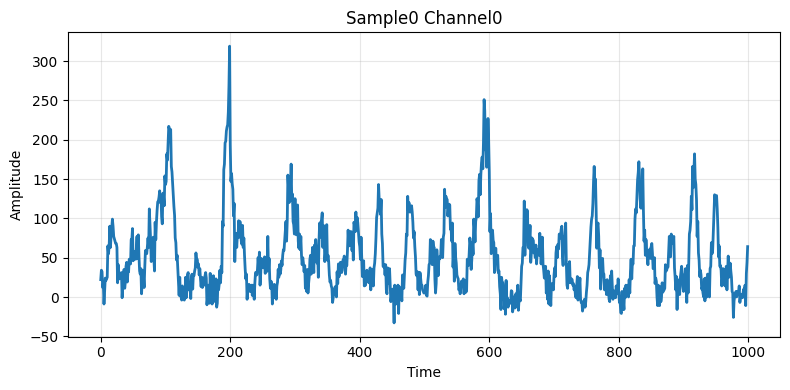

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def plot_1d_signal(signal, title="Signal"):
    plt.figure(figsize=(8, 4))
    plt.plot(signal, linewidth=2)
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
plot_1d_signal(beads_win[:1000, 0], title="Sample0 Channel0")

In [5]:
import numpy as np

n_samples = 100
time_win = 200

# 安全チェック（重要）
assert beads_win.shape[0] >= n_samples * time_win, "データ長が足りません"
assert pbs_win.shape[0] >= n_samples * time_win, "データ長が足りません"

# 非重複切り出し
beads_segments = np.stack([
    beads_win[i*time_win:(i+1)*time_win] for i in range(n_samples)
])

pbs_segments = np.stack([
    pbs_win[i*time_win:(i+1)*time_win] for i in range(n_samples)
])

print("beads_segments.shape:", beads_segments.shape)
print("pbs_segments.shape:", pbs_segments.shape)

beads_segments.shape: (100, 200, 200)
pbs_segments.shape: (100, 200, 200)


In [6]:
np.save("../../data/after_prep_800-1000/beads_segments_7p5W.npy", beads_segments)
np.save("../../data/after_prep_800-1000/pbs_segments_7p5W.npy", pbs_segments)


/var/folders/ft/d5_ys37x417gbwg28lxf87600000gn/T/ipykernel_66936/521165604.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("cividis")


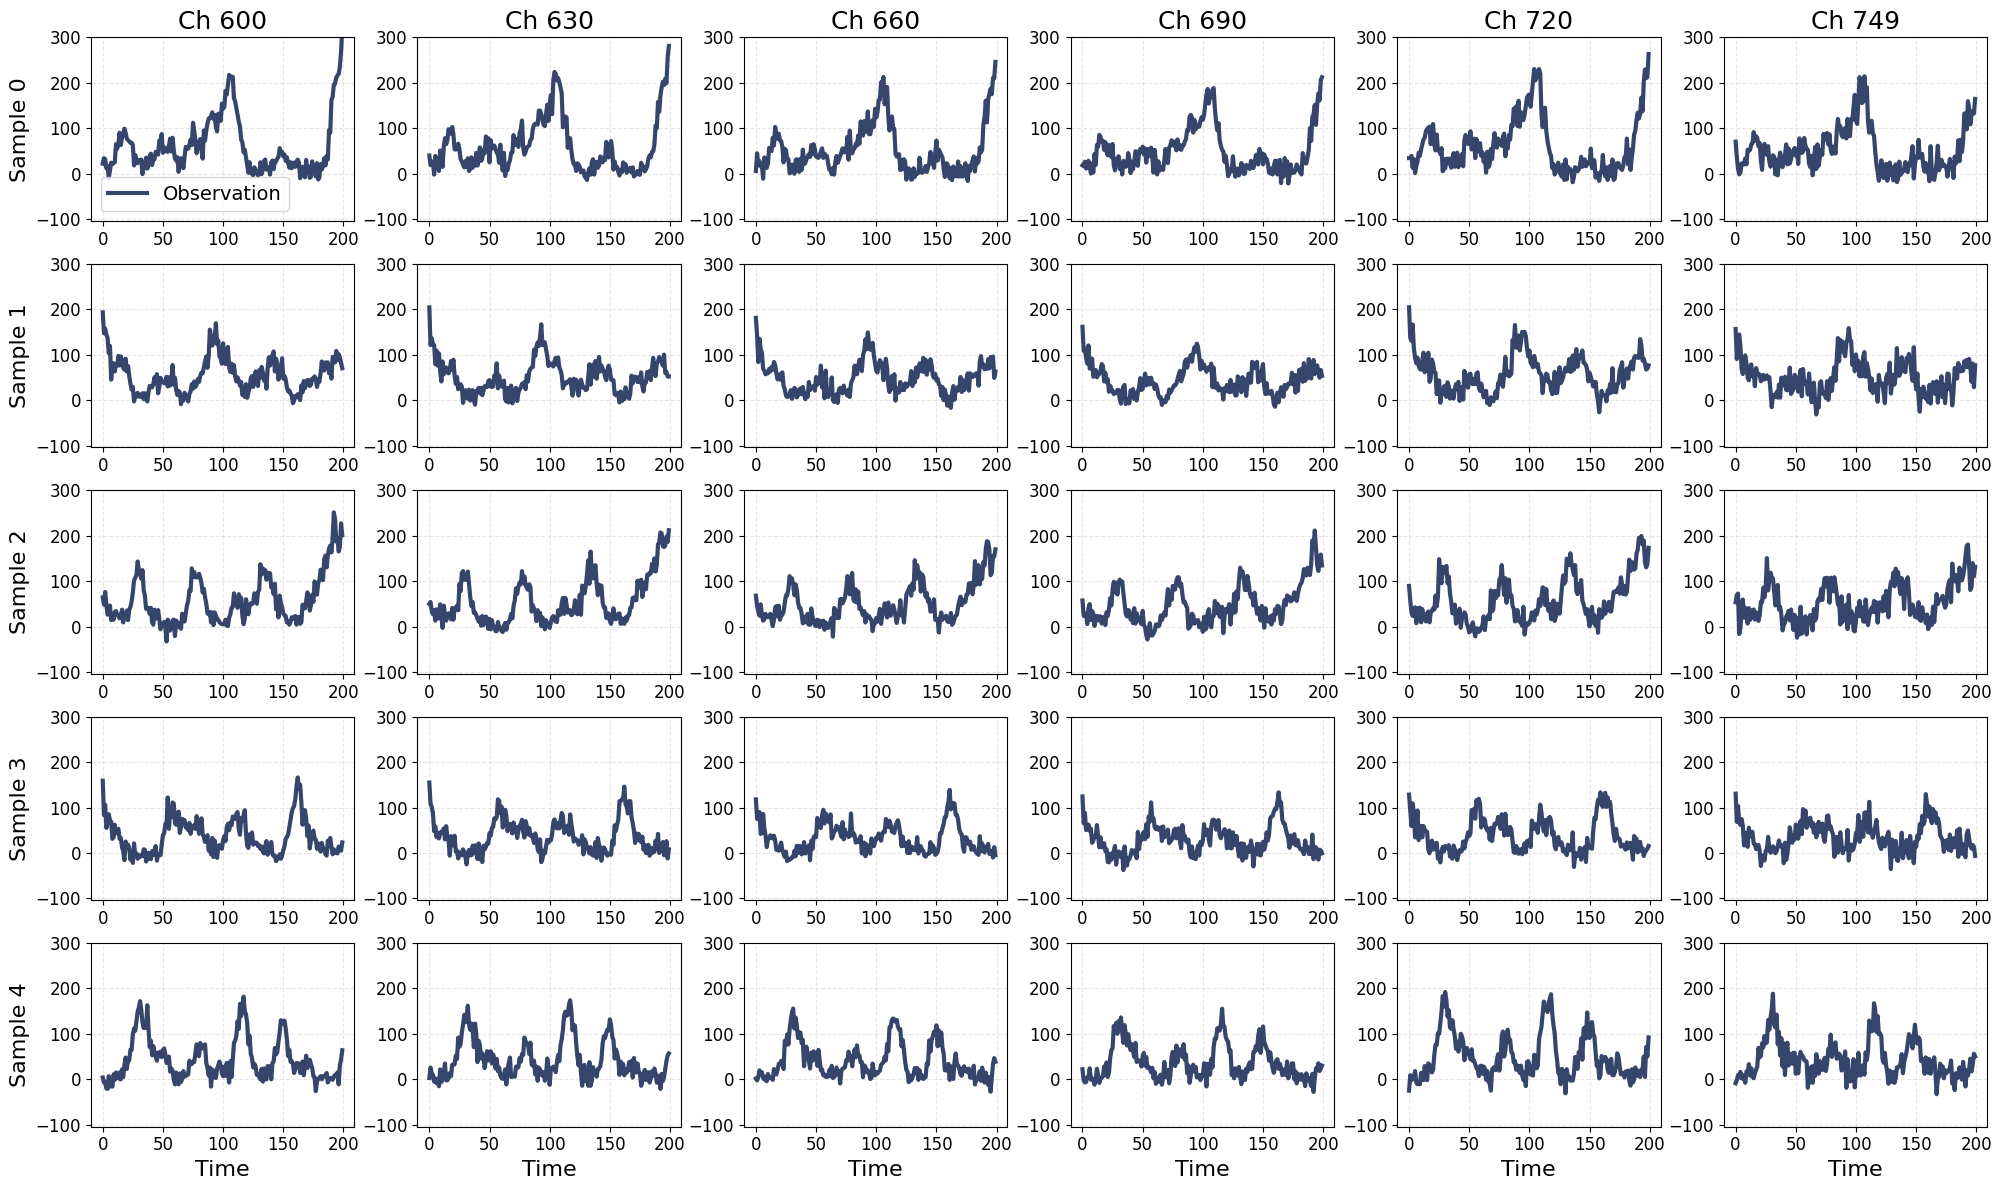

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# =========================
# 設定
# =========================
samples_to_plot = 5
channels = [0, 30, 60, 90, 120, 149]

cmap = cm.get_cmap("cividis")
color_obs = cmap(0.2)
color_avg = cmap(0.8)

fontsize_title = 18
fontsize_label = 16
fontsize_tick = 12
fontsize_legend = 14

# ===== 共通y軸 =====
y_min = beads_segments.min()
y_max = 300

fig, axes = plt.subplots(samples_to_plot, len(channels), figsize=(20, 12))

for i in range(samples_to_plot):
    for j, ch in enumerate(channels):
        ax = axes[i, j]

        ax.plot(beads_segments[i, :, ch], color=color_obs, linewidth=3, label="Observation")

        # 共通y軸
        ax.set_ylim(y_min, y_max)

        # タイトル
        if i == 0:
            ax.set_title(f"Ch {ch+600}", fontsize=fontsize_title)

        # 行ラベル
        if j == 0:
            ax.set_ylabel(f"Sample {i}", fontsize=fontsize_label)

        # 横軸ラベル
        if i == samples_to_plot - 1:
            ax.set_xlabel("Time", fontsize=fontsize_label)

        ax.tick_params(axis='both', labelsize=fontsize_tick)
        ax.grid(True, alpha=0.3, linestyle="--")

        if i == 0 and j == 0:
            ax.legend(fontsize=fontsize_legend)

plt.tight_layout()
plt.show()